In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
def heaviside(x):
    return np.where(x > 0, 1, 0)

def ReLU(x):
    """ Integral of heaviside from -inf to x """
    return np.where(x > 0, x, 0)

def sigmoid(x, lam):
    return 1 / (1 + np.exp(-lam * x))

def softmax(x, lam):
    """Integral from -inf to x of sigmoid(t, lam) dt."""
    return np.logaddexp(0, lam * x) / lam

/var/folders/6p/hll0pcr53rx1zjv426_y3zyr0000gn/T/ipykernel_24209/743919193.py:9: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-lam * x))


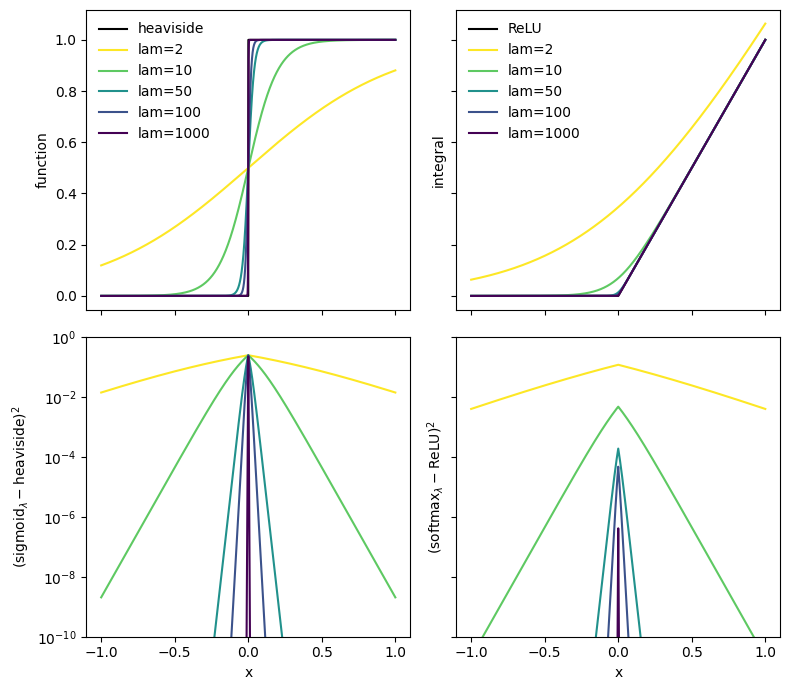

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(8, 7), sharex=True, sharey='row')  # 2 rows, 2 columns, sharex and rows sharey

xlist = np.linspace(-1, 1, 10000)
heaviside_list = heaviside(xlist)
relu_list = ReLU(xlist)
axs[0, 0].plot(xlist, heaviside_list, label='heaviside', c='k')
axs[0, 1].plot(xlist, relu_list, label='ReLU', c='k')

lams = [2, 10, 50, 100, 1000]
colors = plt.cm.viridis(np.linspace(1, 0, len(lams)))
for lam, color in zip(lams, colors):
    sigmoid_list = sigmoid(xlist, lam)
    softmax_list = softmax(xlist, lam)
    axs[0, 0].plot(xlist, sigmoid_list, label=f'lam={lam}', c=color)
    axs[0, 1].plot(xlist, softmax_list, label=f'lam={lam}', c=color)
    
    err = (sigmoid_list - heaviside_list) ** 2
    err_int = (softmax_list - relu_list) ** 2
    axs[1, 0].plot(xlist, err, c=color)
    axs[1, 1].plot(xlist, err_int, c=color)

for ax in axs[1]:
    ax.set(yscale='log', ylim=(1e-10, 1))

# Even smaller, box-less legend for both columns
axs[0, 0].legend(fontsize=10, frameon=False, loc='upper left')
axs[0, 1].legend(fontsize=10, frameon=False, loc='upper left')

# Axis labels
axs[1, 0].set_xlabel('x')
axs[1, 1].set_xlabel('x')
axs[0, 0].set_ylabel('function')
axs[1, 0].set_ylabel(r'$(\mathrm{sigmoid}_\lambda - \mathrm{heaviside})^2$')
axs[0, 1].set_ylabel('integral')
axs[1, 1].set_ylabel(r'$(\mathrm{softmax}_\lambda - \mathrm{ReLU})^2$')

plt.tight_layout()
plt.show()


/var/folders/6p/hll0pcr53rx1zjv426_y3zyr0000gn/T/ipykernel_24209/743919193.py:9: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-lam * x))


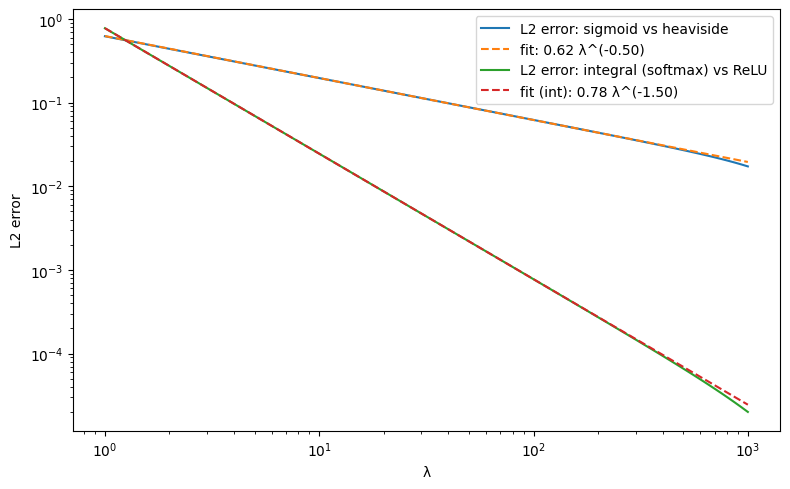

In [54]:
lams = np.logspace(0, 3, 100)
L2err = np.zeros_like(lams)
L2err_int = np.zeros_like(lams)
xlist_int = np.linspace(-100, 100, 100000)
for i, lam in enumerate(lams):
    sigmoid_list = sigmoid(xlist_int, lam)  
    softmax_list = softmax(xlist_int, lam)
    heaviside_list = heaviside(xlist_int)
    relu_list = ReLU(xlist_int)

    err = np.abs(sigmoid_list - heaviside_list)
    err_int = np.abs(softmax_list - relu_list)

    L2err[i] = np.sqrt(np.trapezoid(err**2, x=xlist_int))
    L2err_int[i] = np.sqrt(np.trapezoid(err_int**2, x=xlist_int))

# Fit with a power law: L2err ≈ A * lam**(-alpha), and same for L2err_int
from scipy.optimize import curve_fit

def power_law(lam, A, alpha):
    return A * lam ** (-alpha)

mask = (lams > 10) & (lams < 500)
# fit for sigmoid approximation
popt, pcov = curve_fit(power_law, lams[mask], L2err[mask])
A_fit, alpha_fit = popt
# fit for integral (softmax approximation)
popt_int, pcov_int = curve_fit(power_law, lams[mask], L2err_int[mask])
A_fit_int, alpha_fit_int = popt_int

plt.figure(figsize=(8, 5))
plt.plot(lams, L2err, label='L2 error: sigmoid vs heaviside')
plt.plot(lams, power_law(lams, A_fit, alpha_fit), '--',
         label='fit: {:.2g} λ^(-{:.2f})'.format(A_fit, alpha_fit))
plt.plot(lams, L2err_int, label='L2 error: integral (softmax) vs ReLU')
plt.plot(lams, power_law(lams, A_fit_int, alpha_fit_int), '--',
         label='fit (int): {:.2g} λ^(-{:.2f})'.format(A_fit_int, alpha_fit_int))
plt.yscale('log')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('L2 error')
plt.legend()
plt.tight_layout()
plt.show()